In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

TRAIN_DATASET_DIR = "./learn_dataset_single_object"  # 学習: 単一物体
TEST_DATASET_DIR  = "./learn_dataset_fixed_angle"     # テスト: 2物体同時
TRAIN_META_CSV = os.path.join(TRAIN_DATASET_DIR, "metadata.csv")
TEST_META_CSV  = os.path.join(TEST_DATASET_DIR,  "metadata.csv")
MODEL_PATH = "./best_detector_agnostic.pt"

N_FIXED = 10

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
EPOCHS     = 20
LR         = 1e-3

D_TOL = 2
R_TOL = 3

print("DEVICE:", DEVICE)
print("TRAIN_META_CSV exists:", os.path.exists(TRAIN_META_CSV))
print("TEST_META_CSV  exists:", os.path.exists(TEST_META_CSV))


DEVICE: cpu
TRAIN_META_CSV exists: True
TEST_META_CSV  exists: True


In [3]:
def Radar_setting():
    ###### symbol time & carrier frequency ######
    T_symbol = 5.575 * 1e-6              # symbol duration, with CP time
    T_OFDM = 5.2125 * 1e-6
    f_carrier = 28 * 1e+9
    Tc = 2.545*1e-9                      # sampling time

    ###### tx/rx ######
    N_ant = 16                       # the number of antennas
    # BW = 1.966080e+9                      # chirp bandwidth
    BW = 400*1e+6                    # chirp bandwidth
    BW_sub = BW/N_ant
    N_sample = int(np.floor(T_symbol/Tc))           # the number of samples of single chirp
    rx_sample = 813 + N_sample

    ###### Radar setting ######

    mu = BW_sub/T_symbol * 0.98
    l_speed = 299792458

    lam = l_speed/f_carrier
    env = cyclist_env(f_carrier, N_ant, BW, BW_sub, N_sample, rx_sample, Tc, mu, l_speed)
    return T_symbol,f_carrier,Tc,N_ant,BW,BW_sub,N_sample,rx_sample, mu, l_speed, lam, env

In [4]:
def physical_to_rd_indices(range_m, velocity_mps, N_trans, sym_duration, lam, Tc, range_offset=620, num_range_bins=190):
    c = 299792458.0
    vel_res = lam / (2.0 * sym_duration * N_trans)
    range_res = c * Tc / 2.0

    d_idx = int(np.round(velocity_mps / vel_res)) % N_trans
    r_idx = int(np.round(range_m / range_res - range_offset))

    valid = (0 <= d_idx < N_trans) and (0 <= r_idx < num_range_bins)
    return d_idx, r_idx, valid

In [5]:
def syntax_check(num, idx, y_value, velocity_value, x_pos):
    idx_list = np.zeros(num, dtype=np.int32)
    position, velocity = np.zeros((num, 3)), np.zeros((num, 3))
    i=0
    s = set()
    while i < num:
        # 初期値における距離間隔を保証するための処理
        if idx+10 in s or idx-10 in s or idx in s: continue
        for j in range(-20,20): s.add(idx+j)
        
        idx_list[i] = idx
        position[i] = np.array([x_pos[idx], y_value, 1])
        # v_cy[i] = np.array([np.random.rand(1)[0]*5.56, 0, 0])
        velocity[i] = np.array([velocity_value, 0, 0])
        
        i+=1
    return idx_list, position, velocity

In [6]:
def get_snapshot_data(cy_idx_target, ve_idx_target,x_pos, p_bs, tx, cy_v_value, ve_v_value, num_cy, num_ve, num_rp, sym_duration, N_trans,Tc, env):
    # Cyclistについて
    cy_idx = np.zeros(num_cy, dtype=np.int32)
    p_cy, v_cy = np.zeros((num_cy, 3)), np.zeros((num_cy, 3))
    # 範囲外アクセスを防ぐための処理
    cy_idx, p_cy, v_cy = syntax_check(num_cy, cy_idx_target, 15, cy_v_value, x_pos)
    n_cy = len(p_cy)
    
    # Vehicleについて
    ve_idx = np.zeros(num_ve, dtype=np.int32)
    p_ve, v_ve = np.zeros((num_ve, 3)), np.zeros((num_ve, 3))
    # 範囲外アクセスを防ぐための処理
    ve_idx, p_ve, v_ve = syntax_check(num_ve, ve_idx_target, 7.5, ve_v_value, x_pos)
    n_ve = len(p_ve)

    # ramppostについて
    p_rp, v_rp = np.zeros((num_rp, 3)), np.zeros((num_rp, 3))
    n_rp = len(p_rp)
    
    # csvファイルの読み込み
    cy_idx += 1
    ve_idx += 1

    P_rx_cy, tstemp_rx_cy, phase_cy, P_rx_ve, tstemp_rx_ve, phase_ve, P_rx_rp, tstemp_rx_rp, phase_rp = [], [], [], [], [], [], [], [], []
    # 3番目のデータから読み込み開始（最初の数個はノイズのみのため）
    for i in range(len(cy_idx)):
        df = pd.read_csv("./ped/2.545nano/far/complex-impulse-response-Run{:04d}-Sensor_0_Tx_0_to_Rx_0.csv".format(cy_idx[i]))
        tstemp_rx_cy.append(np.round((df["Time (s)"]/Tc)).values[3:])
        P_rx_cy.append(df["| Total Complex Impulse Response total | (W)"].values[3:])
        phase_cy.append(df['Phase( Total Complex Impulse Response total ) (rad)'].values[3:])
    for i in range(len(ve_idx)):
        df = pd.read_csv("./vehicle/2.545nano/far/complex-impulse-response-Run{:04d}-Sensor_0_Tx_0_to_Rx_0.csv".format(ve_idx[i]))
        tstemp_rx_ve.append(np.round((df["Time (s)"].values[3:]/Tc)))
        P_rx_ve.append(df["| Total Complex Impulse Response total | (W)"].values[3:])
        phase_ve.append(df['Phase( Total Complex Impulse Response total ) (rad)'].values[3:])
    # 2.545のほうを使う！
    for i in range(2,3):
        df = pd.read_csv("./Ramposts/2.545nano/"+str(i)+"/complex-impulse-response-Run0001-Sensor_0_Tx_0_to_Rx_0.csv")
        tstemp_rx_rp.append(np.round((df["Time (s)"].values[5:]/Tc)))
        P_rx_rp.append(df["| Total Complex Impulse Response total | (W)"].values[5:])
        phase_rp.append(df['Phase( Total Complex Impulse Response total ) (rad)'].values[5:])
    phys_quantities = env.phys_quantities(p_bs, p_cy, v_cy, n_cy, p_ve, v_ve, n_ve, p_rp, v_rp, n_rp)
    #print(phys_quantities["relative_velocity"]["cyclists"])
    real_cy_coordinates = []
    real_vel_coordinates = []
    real_rp_coordinates = []

    for i in range(len(p_cy)):
        real_cy_coordinates.append(np.array([p_cy[i][0], p_cy[i][1]]))
    for i in range(len(p_ve)):
        real_vel_coordinates.append(np.array([p_ve[i][0], p_ve[i][1]]))
    for i in range(len(p_rp)):
        real_rp_coordinates.append(np.array([p_rp[i][0], p_rp[i][1]]))
    
        
    ######### We need some functions here. it is like this. read the csv. this outputs the time stemp and corresponding rx value.
    # P_rx_cy_dB = -114
    #P_rx_cy_dB = -111
    #P_rx_ve_dB = -114
    #P_rx_cy_dB = 0
    #P_rx_ve_dB = 0
    
    P_N_dB = -87.98

    Y = env.rx_multiple(tx, P_rx_cy, tstemp_rx_cy, phase_cy, P_rx_ve, tstemp_rx_ve, phase_ve, P_rx_rp, tstemp_rx_rp, phase_rp, P_N_dB, sym_duration, N_trans)
    
    return Y, phys_quantities, real_cy_coordinates, real_vel_coordinates, real_rp_coordinates

In [7]:
def stevec(N_ant, angle):
    # 入力された角度に対するステアリングベクトルの計算
    resp = (np.arange(N_ant)-N_ant*0.5+0.5).reshape([-1,1])
    resp = np.exp(1j*resp*np.pi*np.sin(angle))
    return np.matrix(resp)

In [8]:
def MUSIC_method_improved(Y, N_ant, num_signals, frame_count):
    '''
    修正前
    Y_music = np.mean(Y, axis=0)
    R_yy = Y_music@np.conjugate(np.transpose(Y_music))
    '''
    # 修正後: 
    # チャープ軸(0)とサンプル軸(2)の両方を「スナップショット」として扱います。
    # (N_trans, N_ant, N_sample) -> (N_ant, N_trans * N_sample) に変形
    # これにより、N_trans(チャープ数)が増えるほど、スナップショット数が増え、
    # 共分散行列 R_yy の推定精度が向上します。
    N_trans, N_ant_data, N_sample = Y.shape
    # データを (アンテナ数 x 全サンプル数) の2次元行列に変形
    Y_music = Y.transpose(1, 0, 2).reshape(N_ant_data, -1)
    
    # 共分散行列の計算
    # (行列サイズは アンテナ数 x アンテナ数 のまま変わらないので計算負荷は軽微です)
    R_yy = (Y_music @ np.conjugate(Y_music.T)) / Y_music.shape[1]
    
    # 1.固有値分解
    eig_val, eig_vec = np.linalg.eig(R_yy)
    
    # 2.固有値をソートして雑音部分空間を取得
    idx = np.abs(eig_val).argsort()[::-1]
    # インデックスによって固有値と固有ベクトルの対応関係を維持しつつソート
    eig_val = eig_val[idx]
    eig_vec = eig_vec[:, idx]
    # 雑音部分空間Uを取得

    # num_signalsを固有値から推定?
    
    # デバッグ用
    num_signals = 5
    
    U = eig_vec[:, num_signals:]
    

    # 3.雑音部分空間とvalごとのステアリングベクトルの内積を計算
    resp = []
    argm = (np.arange(1800)-900)/100
    for val in argm:
        # ステアリングベクトルの計算
        stv = stevec(N_ant, val*np.pi/180)
        # 雑音部分空間との内積
        p = stv.T@U
        # L2ノルムの二乗を計算(pp^H)
        pp = p*np.conjugate(np.transpose(p))
        # A1は行列を1次元配列に変換するメソッド
        # respに逆数を追加
        # 分子は角度推定の上では不要なので省略している
        resp.append(1/(np.abs(pp)**2).A1)
    
    # 4.ピーク検出
    M = np.max(resp)
    
    # デバッグ用
    #MUSIC_method_Debug(eig_val, N_ant, num_signals, resp, argm, M, frame_count)
    
    est_ang = []
    # 三点比較によるピーク検出
    a, b = resp[0][0], resp[1][0]
    for i in range(1,len(argm)-1):
        c = resp[i+1][0]
        #if a < b and b > c and b > 0.2 * M:
        if a < b and b > c and b > 0.00001 * M:
            est_ang.append(argm[i])
        a, b = b, c
    return est_ang

In [9]:
def FFT(N_trans, N_ant, rx_sample, Y, tx, N_sample, est_ang, sym_duration, lam, Tc, env):
    # ドップラー処理
    Dopp_dft = dft(N_trans)/np.sqrt(N_trans)
    Y_dft = np.zeros((N_trans, N_ant, rx_sample), dtype=np.complex128)
    for i in range(N_ant):
        Y_dft[:,i,:] = Dopp_dft@Y[:,i,:]
    
    final_objects_all = []
    rd_maps = []

    P_range = np.arange(190)+620

    # FFTによる位置推定処理
    tx_arr = np.array(tx) 
    n_fft = 2**(int(rx_sample + N_sample).bit_length())
    #n_fft = 2048
    
    # 窓関数を掛けずにFFTする
    TX_F_all = fft(tx_arr, n=n_fft, axis=1) 
    Y_F_all = fft(Y_dft, n=n_fft, axis=2)
    
    for i in range(len(est_ang)):
        current_angle = est_ang[i]
        ang_rad = current_angle * np.pi / 180
        
        # ステアリングベクトル (N_ant, 1)
        s_vec = np.array(stevec(N_ant, ang_rad))
        
        # --- 周波数領域でのビームフォーミング ---
        
        # 受信信号の合成: Y_combined = sum(Y * s)
        # s_vec を (1, N_ant, 1) に変形して放送
        # Y_F_all: (N_trans, N_ant, n_fft)
        # 重み付け和をとってアンテナ次元を潰す -> (N_trans, n_fft)
        # 修正前
        w_vec = np.conjugate(s_vec).reshape(1, N_ant, 1)
        Y_F_combined = np.sum(Y_F_all * w_vec, axis=1)
        # 修正後
        w_vec = s_vec.reshape(1, N_ant, 1) 
        Y_F_combined = np.sum(Y_F_all * w_vec, axis=1)

        # 送信信号(レプリカ)の合成: X_combined = sum(X * s*)
        # 元の数式 g = s* s^H X より、Xにかかる重みは s^H (つまり sの共役)
        # TX_F_all: (N_ant, n_fft)
        s_vec_conj_reshape = np.conjugate(s_vec).reshape(N_ant, 1)
        TX_F_combined = np.sum(TX_F_all * s_vec_conj_reshape, axis=0) # -> (n_fft,)

        # --- 相関演算 (Correlation) ---
        # Correlation = IFFT( FFT(Y) * conj(FFT(X)) )
        # Broadcasting: (N_trans, n_fft) * (n_fft,)
        CORR_f = Y_F_combined * np.conjugate(TX_F_combined)
        
        # 時間領域に戻す
        corr_time = ifft(CORR_f, axis=1)

        # --- 必要な範囲を切り出し ---
        rdresp_single = corr_time[:, P_range]

        # --- 結果保存 ---
        rd_maps.append(rdresp_single.copy())
        rd_maps.append(i)

    return rd_maps

In [10]:
def generate_one_sample(sample_id, target_idx):
    T_symbol, f_carrier, Tc, N_ant, BW, BW_sub, N_sample, rx_sample, mu, l_speed, lam, env = Radar_setting()
    N_chirp = 89
    N_trans = N_chirp
    tx = env.tx()

    p_bs = np.array([250, -18, 50])
    x_pos = list(np.arange(-450, -149) / 10)

    if TARGET_KIND == "ped":
        num_cy, num_ve, num_rp = 1, 0, 0
        cy_idx_target = int(target_idx)
        ve_idx_target = 128
        cy_v_value, ve_v_value = 6, 10
        target_label = 0
    else:
        num_cy, num_ve, num_rp = 0, 1, 0
        cy_idx_target = 150
        ve_idx_target = int(target_idx)
        cy_v_value, ve_v_value = 6, 10
        target_label = 1

    Y, phys_quantities, real_cy_coordinates, real_vel_coordinates, real_rp_coordinates = get_snapshot_data(
        cy_idx_target, ve_idx_target, x_pos, p_bs, tx,
        cy_v_value, ve_v_value, num_cy, num_ve, num_rp,
        T_symbol, N_trans, Tc, env
    )

    est_ang = MUSIC_method_improved(Y, N_ant, num_cy + num_ve + num_rp, frame_count=sample_id)
    rd_maps = FFT(N_trans, N_ant, rx_sample, Y, tx, N_sample, est_ang, T_symbol, lam, Tc, env)

    target_kinds = []
    target_labels = []
    true_ranges = []
    true_velocities = []
    true_angle_degs = []
    true_d_idx_list = []
    true_r_idx_list = []
    valid_list = []

    for truth_key, kind_name, label_value in [("cyclists", "ped", 0), ("vehicles", "vehicle", 1)]:
        ranges = np.asarray(phys_quantities["range"][truth_key]).reshape(-1)
        velocities = np.asarray(phys_quantities["relative_velocity"][truth_key]).reshape(-1)
        angles_rad = np.asarray(phys_quantities["angle"][truth_key]).reshape(-1)

        n_obj = min(len(ranges), len(velocities), len(angles_rad))
        for i in range(n_obj):
            range_i = float(ranges[i])
            velocity_i = float(velocities[i])
            angle_deg_i = float(np.degrees(angles_rad[i]))
            d_idx_i, r_idx_i, valid_i = physical_to_rd_indices(
                range_i, velocity_i, N_trans, T_symbol, lam, Tc
            )

            target_kinds.append(kind_name)
            target_labels.append(int(label_value))
            true_ranges.append(range_i)
            true_velocities.append(velocity_i)
            true_angle_degs.append(angle_deg_i)
            true_d_idx_list.append(int(d_idx_i))
            true_r_idx_list.append(int(r_idx_i))
            valid_list.append(int(valid_i))

    if len(target_kinds) == 0:
        raise RuntimeError("No targets found in phys_quantities. Check scenario settings.")

    primary_idx = 0
    for i, kind_name in enumerate(target_kinds):
        if kind_name == TARGET_KIND:
            primary_idx = i
            break

    true_range = true_ranges[primary_idx]
    true_velocity = true_velocities[primary_idx]
    true_angle_deg = true_angle_degs[primary_idx]
    d_idx = true_d_idx_list[primary_idx]
    r_idx = true_r_idx_list[primary_idx]
    valid = valid_list[primary_idx]

    save_path = os.path.join(OUTPUT_DIR, f"sample_{sample_id:05d}.npz")
    np.savez_compressed(
        save_path,
        rd_maps=np.array(rd_maps[::2], dtype=np.complex64),
        est_ang=np.array(est_ang, dtype=np.float32),
        true_range=np.float32(true_range),
        true_velocity=np.float32(true_velocity),
        true_angle_deg=np.float32(true_angle_deg),
        true_d_idx=np.int32(d_idx),
        true_r_idx=np.int32(r_idx),
        true_range_list=np.array(true_ranges, dtype=np.float32),
        true_velocity_list=np.array(true_velocities, dtype=np.float32),
        true_angle_deg_list=np.array(true_angle_degs, dtype=np.float32),
        true_d_idx_list=np.array(true_d_idx_list, dtype=np.int32),
        true_r_idx_list=np.array(true_r_idx_list, dtype=np.int32),
        target_labels=np.array(target_labels, dtype=np.int32),
        valid=np.int32(valid),
        valid_list=np.array(valid_list, dtype=np.int32),
        target_label=np.int32(target_label),
        source_index=np.int32(target_idx),
    )

    return {
        "sample_id": sample_id,
        "file": save_path,
        "target_kind": TARGET_KIND,
        "source_index": target_idx,
        "num_angles": len(est_ang),
        "true_range": true_range,
        "true_velocity": true_velocity,
        "true_angle_deg": true_angle_deg,
        "true_d_idx": d_idx,
        "true_r_idx": r_idx,
        "valid": int(valid),
        "num_targets": int(len(target_kinds)),
        "target_kinds_json": json.dumps(target_kinds, ensure_ascii=False),
        "target_labels_json": json.dumps(target_labels),
        "true_range_list_json": json.dumps(true_ranges),
        "true_velocity_list_json": json.dumps(true_velocities),
        "true_angle_deg_list_json": json.dumps(true_angle_degs),
        "true_d_idx_list_json": json.dumps(true_d_idx_list),
        "true_r_idx_list_json": json.dumps(true_r_idx_list),
        "valid_list_json": json.dumps(valid_list),
    }

In [11]:
class MultiTargetDataset(Dataset):
    def __init__(self, meta_df):
        self.meta_df = meta_df.reset_index(drop=True)

    def __len__(self):
        return len(self.meta_df)

    def __getitem__(self, idx):
        row = self.meta_df.iloc[idx]
        npz_path = row["file"]
        if not os.path.isabs(npz_path):
            npz_path = os.path.normpath(os.path.join(".", npz_path))

        x = load_all_rd_maps(npz_path)
        H, W = x.shape[1], x.shape[2]

        valid_cy = 1 if str(row["valid_cyclist"]).strip() in ("1", "True") else 0
        valid_ve = 1 if str(row["valid_vehicle"]).strip() in ("1", "True") else 0

        # 存在するターゲットのみガウスヒートマップ、不在は全ゼロ
        y_cy = make_gaussian_heatmap(H, W, int(row["cyclist_true_d_idx"]), int(row["cyclist_true_r_idx"])) if valid_cy else np.zeros((H, W), dtype=np.float32)
        y_ve = make_gaussian_heatmap(H, W, int(row["vehicle_true_d_idx"]), int(row["vehicle_true_r_idx"])) if valid_ve else np.zeros((H, W), dtype=np.float32)
        y = np.clip(y_cy + y_ve, 0.0, 1.0)[np.newaxis, :]  # (1, H, W)

        return {
            "x": torch.from_numpy(x).float(),
            "y": torch.from_numpy(y).float(),
            "cy_true_d": torch.tensor(int(row["cyclist_true_d_idx"]), dtype=torch.long),
            "cy_true_r": torch.tensor(int(row["cyclist_true_r_idx"]), dtype=torch.long),
            "ve_true_d": torch.tensor(int(row["vehicle_true_d_idx"]), dtype=torch.long),
            "ve_true_r": torch.tensor(int(row["vehicle_true_r_idx"]), dtype=torch.long),
            "valid_cy": torch.tensor(valid_cy, dtype=torch.long),
            "valid_ve": torch.tensor(valid_ve, dtype=torch.long),
        }


In [12]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels=32, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)

class RadarLightUNet(nn.Module):
    def __init__(self, in_channels=N_FIXED, out_channels=2, fixed_channels=32, dropout=0.1):
        super().__init__()

        self.encoders = nn.ModuleList([
            ConvBlock(in_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
        ])
        self.pools = nn.ModuleList([
            nn.MaxPool2d(2, 2) for _ in range(4)
        ])
        self.bottleneck = ConvBlock(fixed_channels, fixed_channels, dropout)
        self.upsamples = nn.ModuleList([
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
            for _ in range(4)
        ])
        self.decoders = nn.ModuleList([
            ConvBlock(fixed_channels * 2, fixed_channels, dropout)
            for _ in range(4)
        ])
        self.head = nn.Conv2d(fixed_channels, out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)
            x = pool(x)

        x = self.bottleneck(x)

        for up, dec, skip in zip(self.upsamples, self.decoders, reversed(skips)):
            x = up(x)
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)

        return self.head(x)  # logits (B, 2, H, W)

In [13]:
# 学習用: 単一物体データセット
train_all_df = pd.read_csv(TRAIN_META_CSV)
train_all_df = train_all_df[train_all_df["valid_all"] == 1].reset_index(drop=True)

n = len(train_all_df)
n_train = int(n * 0.8)
n_val   = int(n * 0.1)

train_df = train_all_df.iloc[:n_train].reset_index(drop=True)
val_df   = train_all_df.iloc[n_train:n_train+n_val].reset_index(drop=True)

# テスト用: 2物体同時データセット
test_df = pd.read_csv(TEST_META_CSV)
test_df = test_df[test_df["valid_all"] == 1].reset_index(drop=True)

print("train:", len(train_df), "  val:", len(val_df), "  test:", len(test_df))
display(train_df.head())


train: 480   val: 60   test: 300


,file,scenario,cyclist_true_d_idx,cyclist_true_r_idx,vehicle_true_d_idx,vehicle_true_r_idx,valid_cyclist,valid_vehicle,valid_all,source_index
0,./learn_dataset_single_object\sample_00000.npz,cyclist_only,1,168,0,0,True,0,1,1
1,./learn_dataset_single_object\sample_00001.npz,cyclist_only,1,168,0,0,True,0,1,2
2,./learn_dataset_single_object\sample_00002.npz,cyclist_only,1,168,0,0,True,0,1,3
3,./learn_dataset_single_object\sample_00003.npz,cyclist_only,1,168,0,0,True,0,1,4
4,./learn_dataset_single_object\sample_00004.npz,cyclist_only,1,167,0,0,True,0,1,5


In [14]:
def evaluate_split(model, meta_df, batch_size=BATCH_SIZE, device=DEVICE):
    ds = SingleTargetDataset(meta_df.reset_index(drop=True))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    loss, hit = run_epoch(model, loader, optimizer=None, device=device)
    return {
        "count": len(meta_df),
        "loss": loss,
        "hit_rate": hit,
    }

def evaluate_per_kind(model, meta_df, device=DEVICE):
    rows = []

    rows.append({
        "target_kind": "all",
        **evaluate_split(model, meta_df, device=device)
    })

    for target_kind in ["ped", "vehicle"]:
        sub_df = meta_df[meta_df["target_kind"] == target_kind].reset_index(drop=True)
        if len(sub_df) == 0:
            continue

        rows.append({
            "target_kind": target_kind,
            **evaluate_split(model, sub_df, device=device)
        })

    return pd.DataFrame(rows)

In [15]:
def make_gaussian_heatmap(H, W, center_d, center_r, sigma_d=1.5, sigma_r=2.0):
    d = np.arange(H, dtype=np.float32)[:, None]
    r = np.arange(W, dtype=np.float32)[None, :]
    heatmap = np.exp(
        -0.5 * (((d - center_d) / sigma_d) ** 2 + ((r - center_r) / sigma_r) ** 2)
    )
    return heatmap.astype(np.float32)

def load_all_rd_maps(npz_path):
    data = np.load(npz_path)
    rd_maps = data["rd_maps"]
    result = []
    for i in range(rd_maps.shape[0]):
        rd_mag = np.abs(rd_maps[i]).astype(np.float32)
        rd_db = 20.0 * np.log10(np.maximum(rd_mag, 1e-12))
        rd_db = (rd_db - rd_db.mean()) / (rd_db.std() + 1e-6)
        result.append(rd_db)
    return np.stack(result, axis=0)

def decode_peaks_from_logits(logits, threshold=0.8):
    """1chヒートマップから上位2ピークを検出して返す [(d1,r1,conf1),(d2,r2,conf2)]"""
    prob = torch.sigmoid(logits)[0, 0]  # (H, W)
    H, W = prob.shape
    p = prob.clone()
    results = []
    for _ in range(2):
        flat_idx = torch.argmax(p).item()
        d_idx = flat_idx // W
        r_idx = flat_idx % W
        conf = float(prob[d_idx, r_idx].item())
        if conf < threshold:
            break
        results.append((d_idx, r_idx, conf))
        d0, d1 = max(0, d_idx-3), min(H, d_idx+4)
        r0, r1 = max(0, r_idx-3), min(W, r_idx+4)
        p[d0:d1, r0:r1] = 0.0
    return results

def compute_hit(pred_d, pred_r, true_d, true_r, d_tol=D_TOL, r_tol=R_TOL):
    return (abs(pred_d - true_d) <= d_tol) and (abs(pred_r - true_r) <= r_tol)


In [16]:
def dice_loss_from_logits(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(2, 3))
    den = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + eps
    return (1 - num / den).mean()

def compute_loss(logits, targets, pos_weight=20.0):
    bce = F.binary_cross_entropy_with_logits(
        logits, targets,
        pos_weight=torch.tensor(pos_weight, device=logits.device)
    )
    dice = dice_loss_from_logits(logits, targets)
    return bce + dice

def match_peaks_to_targets(peaks, cy_true_d, cy_true_r, ve_true_d, ve_true_r):
    import itertools
    if len(peaks) == 0:
        return (-1, -1), (-1, -1)
    if len(peaks) == 1:
        p = peaks[0][:2]
        cy_dist = (p[0]-cy_true_d)**2 + (p[1]-cy_true_r)**2
        ve_dist = (p[0]-ve_true_d)**2 + (p[1]-ve_true_r)**2
        if cy_dist <= ve_dist:
            return p, (-1, -1)
        else:
            return (-1, -1), p
    best_cy, best_ve = peaks[0][:2], peaks[1][:2]
    best_cost = float('inf')
    for p1, p2 in itertools.permutations(peaks[:2]):
        cost = ((p1[0]-cy_true_d)**2 + (p1[1]-cy_true_r)**2 +
                (p2[0]-ve_true_d)**2 + (p2[1]-ve_true_r)**2)
        if cost < best_cost:
            best_cost = cost
            best_cy, best_ve = p1[:2], p2[:2]
    return best_cy, best_ve

def run_epoch(model, loader, optimizer=None, device='cpu'):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    cy_hits, cy_total = 0, 0
    ve_hits, ve_total = 0, 0

    for batch in loader:
        x = batch['x'].to(device)
        y = batch['y'].to(device)
        cy_true_d = batch['cy_true_d'].cpu().numpy()
        cy_true_r = batch['cy_true_r'].cpu().numpy()
        ve_true_d = batch['ve_true_d'].cpu().numpy()
        ve_true_r = batch['ve_true_r'].cpu().numpy()
        valid_cy  = batch['valid_cy'].cpu().numpy()
        valid_ve  = batch['valid_ve'].cpu().numpy()

        if train_mode:
            optimizer.zero_grad()

        logits = model(x)
        loss = compute_loss(logits, y)

        if train_mode:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)

        for i in range(x.size(0)):
            peaks = decode_peaks_from_logits(logits[i:i+1].detach().cpu())
            (cy_d, cy_r), (ve_d, ve_r) = match_peaks_to_targets(
                peaks, int(cy_true_d[i]), int(cy_true_r[i]),
                int(ve_true_d[i]), int(ve_true_r[i])
            )
            if valid_cy[i]:
                cy_hits  += int(compute_hit(cy_d, cy_r, int(cy_true_d[i]), int(cy_true_r[i])))
                cy_total += 1
            if valid_ve[i]:
                ve_hits  += int(compute_hit(ve_d, ve_r, int(ve_true_d[i]), int(ve_true_r[i])))
                ve_total += 1

    n = len(loader.dataset)
    mean_loss   = total_loss / max(n, 1)
    cy_hit_rate = cy_hits / max(cy_total, 1)
    ve_hit_rate = ve_hits / max(ve_total, 1)
    return mean_loss, cy_hit_rate, ve_hit_rate


In [17]:
train_ds = MultiTargetDataset(train_df)
val_ds   = MultiTargetDataset(val_df)
test_ds  = MultiTargetDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

model = RadarLightUNet(in_channels=N_FIXED, out_channels=1).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val = float("inf")
history = []

for epoch in range(EPOCHS):
    train_loss, train_cy_hit, train_ve_hit = run_epoch(model, train_loader, optimizer=optimizer, device=DEVICE)
    val_loss,   val_cy_hit,   val_ve_hit   = run_epoch(model, val_loader,   optimizer=None,      device=DEVICE)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_cy_hit": train_cy_hit,
        "train_ve_hit": train_ve_hit,
        "val_loss": val_loss,
        "val_cy_hit": val_cy_hit,
        "val_ve_hit": val_ve_hit,
    })

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), MODEL_PATH)

    print(
        f"epoch={epoch+1:02d} "
        f"train_loss={train_loss:.4f} cy={train_cy_hit:.3f} ve={train_ve_hit:.3f} | "
        f"val_loss={val_loss:.4f}   cy={val_cy_hit:.3f} ve={val_ve_hit:.3f}"
    )

print("best model saved to:", MODEL_PATH)
hist_df = pd.DataFrame(history)
display(hist_df.tail())

epoch=01 train_loss=1.0561 cy=0.000 ve=0.000 | val_loss=0.7375   cy=0.000 ve=0.000
epoch=02 train_loss=0.6673 cy=0.160 ve=0.144 | val_loss=0.4590   cy=0.000 ve=0.967
epoch=03 train_loss=0.4644 cy=0.983 ve=0.911 | val_loss=0.4488   cy=0.000 ve=0.883
epoch=04 train_loss=0.4127 cy=0.997 ve=0.894 | val_loss=0.4127   cy=0.000 ve=0.933
epoch=05 train_loss=0.3911 cy=0.997 ve=0.906 | val_loss=0.3912   cy=0.000 ve=0.750
epoch=06 train_loss=0.3830 cy=0.987 ve=0.911 | val_loss=0.3815   cy=0.000 ve=1.000
epoch=07 train_loss=0.3787 cy=0.997 ve=0.939 | val_loss=0.3803   cy=0.000 ve=1.000
epoch=08 train_loss=0.3731 cy=1.000 ve=0.950 | val_loss=0.3732   cy=0.000 ve=1.000
epoch=09 train_loss=0.3733 cy=0.983 ve=0.911 | val_loss=0.3941   cy=0.000 ve=0.733
epoch=10 train_loss=0.3837 cy=0.937 ve=0.911 | val_loss=0.3701   cy=0.000 ve=0.983
epoch=11 train_loss=0.3699 cy=0.980 ve=0.944 | val_loss=0.3651   cy=0.000 ve=0.983
epoch=12 train_loss=0.3665 cy=0.990 ve=0.956 | val_loss=0.3635   cy=0.000 ve=1.000
epoc

,epoch,train_loss,train_cy_hit,train_ve_hit,val_loss,val_cy_hit,val_ve_hit
15,16,0.360934,1.0,0.994444,0.359214,0.0,1.0
16,17,0.359330,1.0,1.000000,0.358043,0.0,1.0
17,18,0.359841,1.0,1.000000,0.358821,0.0,1.0
18,19,0.360011,1.0,0.977778,0.358367,0.0,1.0
19,20,0.358758,1.0,1.000000,0.356908,0.0,1.0


In [18]:
best_model = RadarLightUNet(in_channels=N_FIXED, out_channels=1).to(DEVICE)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
best_model.eval()

test_loss, test_cy_hit, test_ve_hit = run_epoch(best_model, test_loader, optimizer=None, device=DEVICE)
print(f"test_loss={test_loss:.4f}  cyclist_hit={test_cy_hit:.3f}  vehicle_hit={test_ve_hit:.3f}")

test_loss=0.3926  cyclist_hit=0.960  vehicle_hit=0.883


=== sample 0 ===
[detection 1] d=1, r=168, conf=1.000
[detection 2] d=1, r=99, conf=1.000
[true] cyclist=(1,168)  vehicle=(1,99)


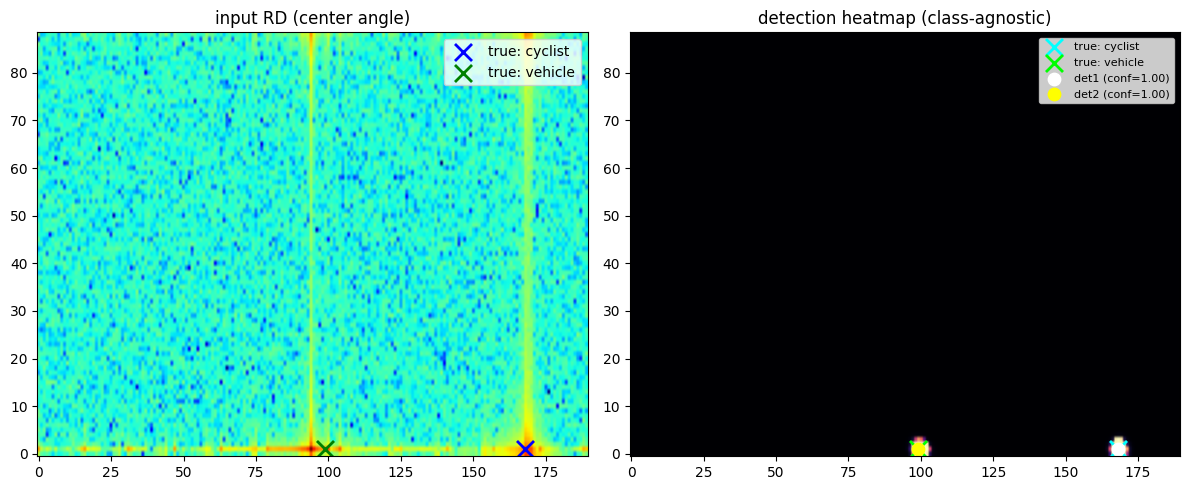

=== sample 1 ===
[detection 1] d=1, r=168, conf=1.000
[detection 2] d=1, r=91, conf=1.000
[true] cyclist=(1,168)  vehicle=(1,91)


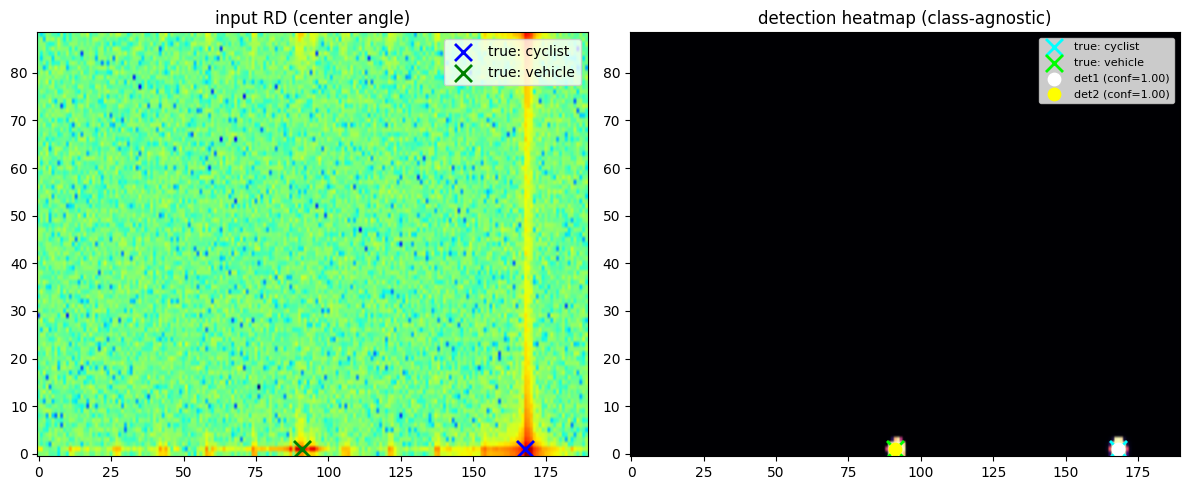

In [19]:
def show_prediction(sample_idx=0):
    row = test_df.iloc[sample_idx]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        logits = best_model(x_tensor)

    # 検出結果: クラスなし、上位2ピーク
    peaks = decode_peaks_from_logits(logits.cpu())
    det1_d, det1_r, det1_conf = peaks[0]
    det2_d, det2_r, det2_conf = peaks[1]

    # 正解: シナリオの情報として表示
    cy_true_d = int(row["cyclist_true_d_idx"])
    cy_true_r = int(row["cyclist_true_r_idx"])
    ve_true_d = int(row["vehicle_true_d_idx"])
    ve_true_r = int(row["vehicle_true_r_idx"])

    print(f"=== sample {sample_idx} ===")
    print(f"[detection 1] d={det1_d}, r={det1_r}, conf={det1_conf:.3f}")
    print(f"[detection 2] d={det2_d}, r={det2_r}, conf={det2_conf:.3f}")
    print(f"[true] cyclist=({cy_true_d},{cy_true_r})  vehicle=({ve_true_d},{ve_true_r})")

    rd_db   = x[N_FIXED // 2]
    heatmap = torch.sigmoid(logits)[0, 0].cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(rd_db, aspect="auto", origin="lower", cmap="jet")
    axes[0].scatter([cy_true_r], [cy_true_d], c="blue",  marker="x", s=150, linewidths=2, label="true: cyclist")
    axes[0].scatter([ve_true_r], [ve_true_d], c="green", marker="x", s=150, linewidths=2, label="true: vehicle")
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    axes[1].imshow(heatmap, aspect="auto", origin="lower", cmap="magma")
    axes[1].scatter([cy_true_r], [cy_true_d], c="cyan",   marker="x", s=150, linewidths=2, label="true: cyclist")
    axes[1].scatter([ve_true_r], [ve_true_d], c="lime",   marker="x", s=150, linewidths=2, label="true: vehicle")
    axes[1].scatter([det1_r], [det1_d], c="white",  marker="o", s=80, label=f"det1 (conf={det1_conf:.2f})")
    axes[1].scatter([det2_r], [det2_d], c="yellow", marker="o", s=80, label=f"det2 (conf={det2_conf:.2f})")
    axes[1].set_title("detection heatmap (class-agnostic)")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

show_prediction(sample_idx=0)
show_prediction(sample_idx=1)


vehicle失敗: 計35件
  近接 (|cy_r - ve_r| <= 6): 27件
  遠隔 (|cy_r - ve_r| >  6): 8件


C:\Users\kousu\AppData\Local\Temp\ipykernel_10896\3454848891.py:33: UserWarning: Glyph 36817 (\N{CJK UNIFIED IDEOGRAPH-8FD1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_10896\3454848891.py:33: UserWarning: Glyph 25509 (\N{CJK UNIFIED IDEOGRAPH-63A5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_10896\3454848891.py:33: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_10896\3454848891.py:33: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_10896\3454848891.py:33: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_10896\3454848891.py:33: UserWarning: Glyph 12531 (\N{KA

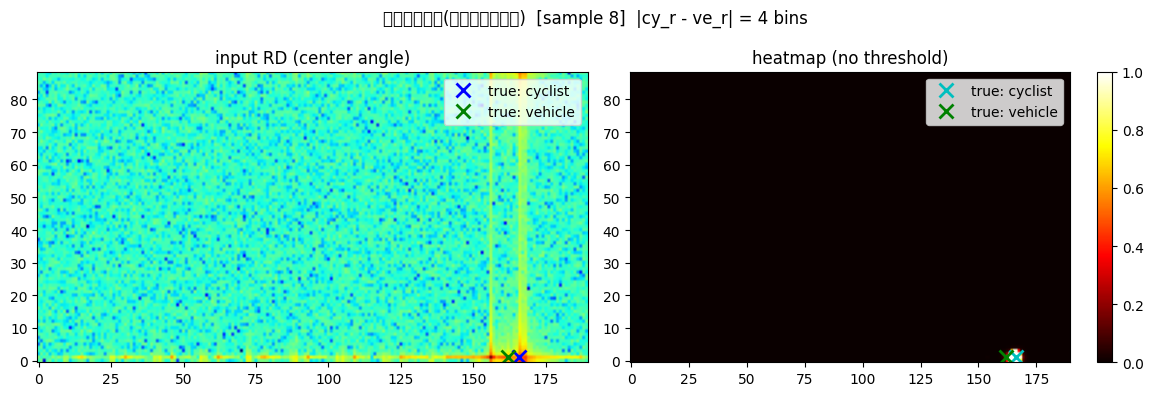

C:\Users\kousu\AppData\Local\Temp\ipykernel_10896\3454848891.py:33: UserWarning: Glyph 36960 (\N{CJK UNIFIED IDEOGRAPH-9060}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_10896\3454848891.py:33: UserWarning: Glyph 38548 (\N{CJK UNIFIED IDEOGRAPH-9694}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_10896\3454848891.py:33: UserWarning: Glyph 38334 (\N{CJK UNIFIED IDEOGRAPH-95BE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_10896\3454848891.py:33: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_10896\3454848891.py:33: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_10896\3454848891.py:33: UserWarning: Glyph 36948 (\

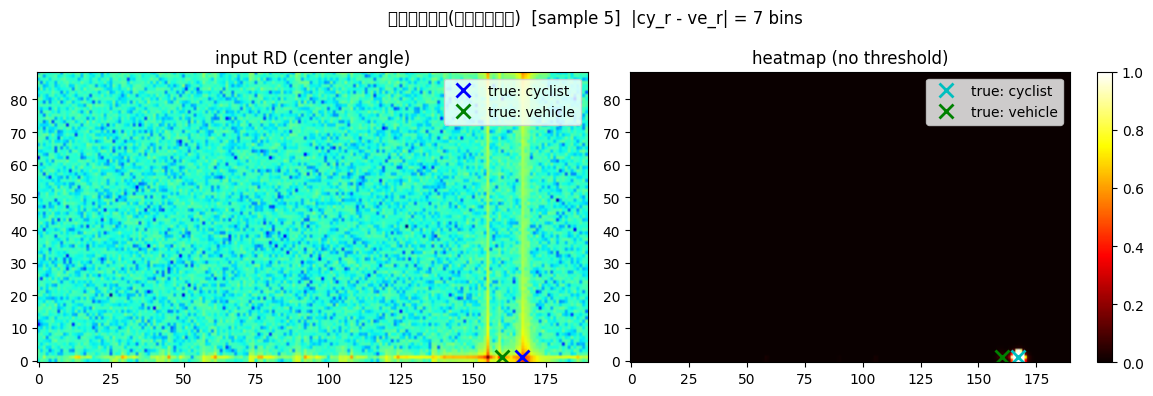

In [ ]:
def show_failure_pattern(sample_idx, title=""):
    row = test_df.iloc[sample_idx]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = best_model(x_tensor)
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()  # threshold なし

    cy_r = int(row['cyclist_true_r_idx'])
    ve_r = int(row['vehicle_true_r_idx'])
    cy_d = int(row['cyclist_true_d_idx'])
    ve_d = int(row['vehicle_true_d_idx'])
    rd_center = x[N_FIXED // 2]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{title}  [sample {sample_idx}]  |cy_r - ve_r| = {abs(cy_r - ve_r)} bins")

    axes[0].imshow(rd_center, aspect='auto', origin='lower', cmap='jet')
    axes[0].plot(cy_r, cy_d, 'bx', ms=10, mew=2, label='true: cyclist')
    axes[0].plot(ve_r, ve_d, 'gx', ms=10, mew=2, label='true: vehicle')
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    im = axes[1].imshow(prob, aspect='auto', origin='lower', cmap='hot', vmin=0, vmax=1)
    axes[1].plot(cy_r, cy_d, 'cx', ms=10, mew=2, label='true: cyclist')
    axes[1].plot(ve_r, ve_d, 'gx', ms=10, mew=2, label='true: vehicle')
    axes[1].set_title("heatmap (no threshold)")
    axes[1].legend()
    plt.colorbar(im, ax=axes[1])
    plt.tight_layout()
    plt.show()

# vehicle失敗サンプルを近接・遠隔に分類
ve_fail_df = pred_df[pred_df['ve_hit'] == 0].copy()
ve_fail_df['r_diff'] = abs(ve_fail_df['cy_true_r'] - ve_fail_df['ve_true_r'])

merge_cases    = ve_fail_df[ve_fail_df['r_diff'] <= 6]   # ピーク合成が疑われる
thresh_cases   = ve_fail_df[ve_fail_df['r_diff'] >  6]   # 閾値未達が疑われる

print(f"vehicle失敗: 計{len(ve_fail_df)}件")
print(f"  近接 (|cy_r - ve_r| <= 6): {len(merge_cases)}件")
print(f"  遠隔 (|cy_r - ve_r| >  6): {len(thresh_cases)}件")

# 各パターンの例を1件ずつ表示
if len(merge_cases) > 0:
    idx = merge_cases.iloc[0]['sample_idx']
    show_failure_pattern(int(idx), title="A")

if len(thresh_cases) > 0:
    idx = thresh_cases.iloc[0]['sample_idx']
    show_failure_pattern(int(idx), title="B")

In [20]:
# (旧セル - e50f149aに統合済みのため空)
pass


In [24]:
def collect_predictions(meta_df):
    rows = []
    for i in range(len(meta_df)):
        row = meta_df.iloc[i]
        npz_path = row['file']
        if not os.path.isabs(npz_path):
            npz_path = os.path.normpath(os.path.join('.', npz_path))
        x = load_all_rd_maps(npz_path)
        x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
        with torch.no_grad():
            logits = best_model(x_tensor)
        peaks = decode_peaks_from_logits(logits.cpu())

        # ピーク数が可変なのでデフォルト値-1で埋める
        det1_d, det1_r, det1_conf = peaks[0] if len(peaks) > 0 else (-1, -1, 0.0)
        det2_d, det2_r, det2_conf = peaks[1] if len(peaks) > 1 else (-1, -1, 0.0)

        cy_true_d = int(row['cyclist_true_d_idx'])
        cy_true_r = int(row['cyclist_true_r_idx'])
        ve_true_d = int(row['vehicle_true_d_idx'])
        ve_true_r = int(row['vehicle_true_r_idx'])

        (cy_d, cy_r), (ve_d, ve_r) = match_peaks_to_targets(
            peaks, cy_true_d, cy_true_r, ve_true_d, ve_true_r
        )

        rows.append({
            'sample_idx': i,
            'file': row['file'],
            'det1_d': det1_d, 'det1_r': det1_r, 'det1_conf': det1_conf,
            'det2_d': det2_d, 'det2_r': det2_r, 'det2_conf': det2_conf,
            'cy_true_d': cy_true_d, 'cy_true_r': cy_true_r,
            've_true_d': ve_true_d, 've_true_r': ve_true_r,
            'cy_d_err': cy_d - cy_true_d, 'cy_r_err': cy_r - cy_true_r,
            've_d_err': ve_d - ve_true_d, 've_r_err': ve_r - ve_true_r,
            'cy_hit': compute_hit(cy_d, cy_r, cy_true_d, cy_true_r),
            've_hit': compute_hit(ve_d, ve_r, ve_true_d, ve_true_r),
        })
    return pd.DataFrame(rows)

In [25]:
pred_df = collect_predictions(test_df)

print("=== hit rate ===")
print(f"cyclist正解への検出率: {pred_df['cy_hit'].mean():.3f}")
print(f"vehicle正解への検出率: {pred_df['ve_hit'].mean():.3f}")

print("=== cyclist 失敗例 ===")
display(pred_df[pred_df["cy_hit"] == False][["cy_true_d","cy_true_r","det1_d","det1_r","det2_d","det2_r"]].head())
print("=== vehicle 失敗例 ===")
display(pred_df[pred_df["ve_hit"] == False][["ve_true_d","ve_true_r","det1_d","det1_r","det2_d","det2_r"]].head())


=== hit rate ===
cyclist正解への検出率: 0.960
vehicle正解への検出率: 0.883
=== cyclist 失敗例 ===


,cy_true_d,cy_true_r,det1_d,det1_r,det2_d,det2_r
26,1,162,1,166,-1,-1
60,1,153,1,157,-1,-1
75,1,149,1,148,-1,-1
78,1,148,1,152,-1,-1
94,1,144,1,151,-1,-1


=== vehicle 失敗例 ===


,ve_true_d,ve_true_r,det1_d,det1_r,det2_d,det2_r
5,1,160,1,167,-1,-1
8,1,162,1,165,-1,-1
17,1,153,1,164,-1,-1
32,1,154,1,159,-1,-1
37,1,159,1,159,-1,-1


In [28]:
# hitサンプルのみで誤差を計算
cy_hit_df = pred_df[pred_df['cy_hit'] == 1]
ve_hit_df = pred_df[pred_df['ve_hit'] == 1]

print("=== 誤差統計 (hit samples only) ===")
err_cols = pd.DataFrame({
    'cy_d_err': cy_hit_df['cy_d_err'],
    'cy_r_err': cy_hit_df['cy_r_err'],
    've_d_err': ve_hit_df['ve_d_err'],
    've_r_err': ve_hit_df['ve_r_err'],
})
print(err_cols.describe().loc[['mean','std','max','min']])


=== 誤差統計 (hit samples only) ===
      cy_d_err  cy_r_err  ve_d_err  ve_r_err
mean       0.0 -0.083333       0.0 -0.049057
std        0.0  0.613438       0.0  0.675217
max        0.0  3.000000       0.0  3.000000
min        0.0 -2.000000       0.0 -2.000000


In [27]:
# === 単一物体サンプルでのチャンネル抑制確認 ===
# cyclist_only → ch0にピーク・ch1がフラット になるか
# vehicle_only → ch0がフラット・ch1にピーク になるか

def show_channel_suppression(scenario, sample_idx=0):
    single_df = pd.read_csv("./learn_dataset_single_object/metadata.csv")
    single_df = single_df[single_df["scenario"] == scenario].reset_index(drop=True)
    row = single_df.iloc[sample_idx]

    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        logits = best_model(x_tensor)

    heatmap = torch.sigmoid(logits)[0, 0].cpu().numpy()  # (H, W) 1chのみ

    peaks = decode_peaks_from_logits(logits.cpu())
    det1_d, det1_r, det1_conf = peaks[0]
    det2_d, det2_r, det2_conf = peaks[1]

    valid_cy = 1 if str(row["valid_cyclist"]).strip() in ("1", "True") else 0
    valid_ve = 1 if str(row["valid_vehicle"]).strip() in ("1", "True") else 0
    cy_true_d = int(row["cyclist_true_d_idx"])
    cy_true_r = int(row["cyclist_true_r_idx"])
    ve_true_d = int(row["vehicle_true_d_idx"])
    ve_true_r = int(row["vehicle_true_r_idx"])

    print(f"scenario: {scenario}")
    print(f"det1: d={det1_d}, r={det1_r}, conf={det1_conf:.4f}")
    print(f"det2: d={det2_d}, r={det2_r}, conf={det2_conf:.4f}")

    rd_db = x[N_FIXED // 2]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"scenario={scenario}", fontsize=13)

    axes[0].imshow(rd_db, aspect="auto", origin="lower", cmap="jet")
    if valid_cy:
        axes[0].scatter([cy_true_r], [cy_true_d], c="blue",  marker="x", s=150, linewidths=2, label="true: cyclist")
    if valid_ve:
        axes[0].scatter([ve_true_r], [ve_true_d], c="green", marker="x", s=150, linewidths=2, label="true: vehicle")
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    axes[1].imshow(heatmap, aspect="auto", origin="lower", cmap="magma")
    if valid_cy:
        axes[1].scatter([cy_true_r], [cy_true_d], c="cyan",  marker="x", s=150, linewidths=2, label="true: cyclist")
    if valid_ve:
        axes[1].scatter([ve_true_r], [ve_true_d], c="lime",  marker="x", s=150, linewidths=2, label="true: vehicle")
    axes[1].scatter([det1_r], [det1_d], c="white",  marker="o", s=80, label=f"det1 conf={det1_conf:.2f}")
    axes[1].scatter([det2_r], [det2_d], c="yellow", marker="o", s=80, label=f"det2 conf={det2_conf:.2f}")
    axes[1].set_title("detection heatmap")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

show_channel_suppression("cyclist_only", sample_idx=0)
show_channel_suppression("vehicle_only", sample_idx=0)


IndexError: list index out of range